In [3]:
from dft_ab import run_dft_ab
from gpaw import restart
from gpaw.new.ase_interface import ASECalculator
import ase
from extract_pi_dft_bands import save_pi_dft_bands, load_pi_dft_bands

In [4]:
filename = 'ab.gpw'
filepath = '../gpw/' + filename


In [4]:
run_dft_ab(filename)

Total energy: -36.857529 eV
File saved to ../ab.gpw


## DFT

In [5]:
atoms, calc = restart(filepath)
atoms: ase.atoms.Atoms # for hints
calc: ASECalculator

In [80]:
save_pi_dft_bands(atoms, calc, path=['M', 'K', 'G'])

[[ 1.27707018 -0.73731681  0.        ]
 [ 1.25046456 -0.78339912  0.        ]
 [ 1.22385893 -0.82948142  0.        ]
 [ 1.1972533  -0.87556372  0.        ]
 [ 1.17064767 -0.92164602  0.        ]
 [ 1.14404204 -0.96772832  0.        ]
 [ 1.11743641 -1.01381062  0.        ]
 [ 1.09083078 -1.05989292  0.        ]
 [ 1.06422515 -1.10597522  0.        ]
 [ 1.03761952 -1.15205752  0.        ]
 [ 1.0110139  -1.19813982  0.        ]
 [ 0.98440827 -1.24422212  0.        ]
 [ 0.95780264 -1.29030443  0.        ]
 [ 0.93119701 -1.33638673  0.        ]
 [ 0.90459138 -1.38246903  0.        ]
 [ 0.87798575 -1.42855133  0.        ]
 [ 0.85138012 -1.47463363  0.        ]
 [ 0.82558073 -1.42994776  0.        ]
 [ 0.79978133 -1.38526189  0.        ]
 [ 0.77398193 -1.34057603  0.        ]
 [ 0.74818253 -1.29589016  0.        ]
 [ 0.72238313 -1.25120429  0.        ]
 [ 0.69658374 -1.20651842  0.        ]
 [ 0.67078434 -1.16183256  0.        ]
 [ 0.64498494 -1.11714669  0.        ]
 [ 0.61918554 -1.07246082

In [81]:
kpts, E_pi, band_indices, EF = load_pi_dft_bands()

In [82]:
EF

array(-2.19881375)

## TB

In [83]:
from tb_bands import TBBandManager
import numpy as np
theta0 = np.array([
            3.1,  # gamma0
            0.39,  # gamma1
            0.315,  # gamma3
            0.044,  # gamma4
            0.0, 0.0, 0.0, 0.0  # epsA1, epsB1, epsA2, epsB2
        ])
manager = TBBandManager(atoms)

manager.create_3d_plot(theta0)


File saved in ../data/3d_bands.html


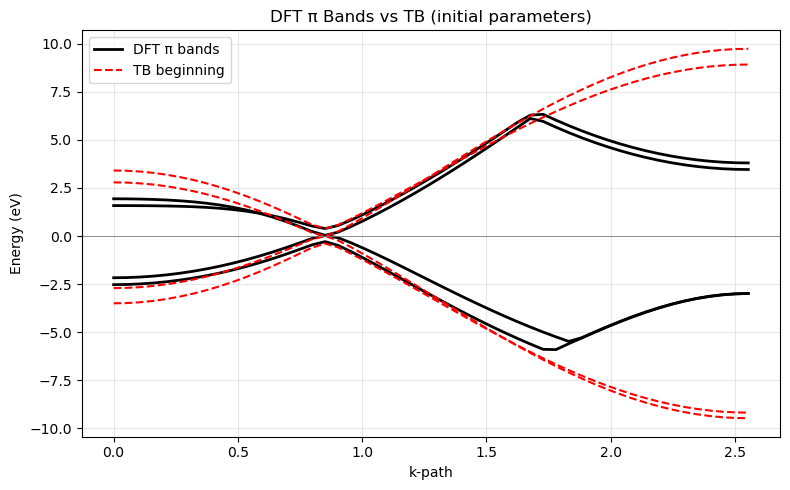

In [89]:
from bandplot import plot_bands

# Compute TB bands:
E_tb_0 = manager.tb_bands(kpts, theta0)

# Number of bands in the DFT π set
nb = E_pi.shape[1]

bands = {
    "DFT π bands": {
        "E": E_pi,         # shape (Nk, nb)
        "color": "k",
        "ls": "-",
        "lw": 2,
    },
    "TB beginning": {
        "E": E_tb_0[:, :nb],   # match π bands only
        "color": "r",
        "ls": "--",
        "lw": 1.5,
    }
}

plot_bands(kpts, bands,
           title="DFT π Bands vs TB (initial parameters)")


In [85]:
from tb_parameters_optimizer import optimize
E_pi_ordered = E_pi[:, [2, 0, 1, 3]] # IMPORTANT! Must reorder bands so that they match from the two models.

theta_fit = optimize(manager, theta0, kpts, E_pi_ordered, 0.5, 1.5)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.2031e+00                                    1.44e+01    
       1              3         1.0135e+00      3.19e+00       7.85e-01       2.31e+00    
       2              4         6.4089e-01      3.73e-01       3.81e-01       5.62e-01    
       3              5         6.3817e-01      2.72e-03       1.91e-01       4.89e-01    
       4              6         6.1831e-01      1.99e-02       4.79e-02       1.79e-01    
       5              7         6.1120e-01      7.11e-03       9.57e-02       7.07e-02    
       6              9         6.1041e-01      7.91e-04       1.51e-02       1.40e-02    
       7             11         6.1034e-01      7.56e-05       5.65e-03       4.02e-03    
       8             13         6.1032e-01      1.11e-05       2.02e-03       2.07e-03    
       9             14         6.1032e-01      1.20e-06       3.65e-03       3.08e-03    

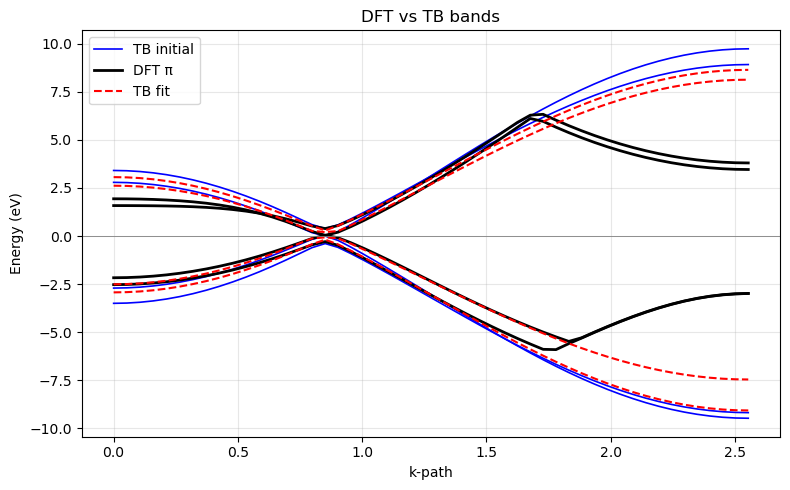

In [86]:
import matplotlib.pyplot as plt
import numpy as np

dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = manager.tb_bands(kpts, theta0)
E_tb_fit = manager.tb_bands(kpts, theta_fit)


from bandplot import plot_bands

bands = {
    "TB initial": {
        "E": E_tb_0,
        "color": "b",
        "ls": "-",
        "lw": 1.2
    },
    "DFT π": {
        "E": E_pi,
        "color": "k",
        "ls": "-",
        "lw": 2
    },
    "TB fit": {
        "E": E_tb_fit,
        "color": "r",
        "ls": "--",
        "lw": 1.5
    }
}

plot_bands(kpts, bands, title="DFT vs TB bands")


## Zoom in
Now we want to zoom in to see the result. We need to rer

In [87]:
from ase.dft.kpoints import get_bandpath
path = ['M', 'K', 'G']
bp = get_bandpath(path, atoms.cell)

k_point = bp.special_points['K']
k_point

array([ 0.33333333, -0.33333333,  0.        ])

In [88]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
%reload_ext autoreload

In [61]:
from extract_pi_dft_bands import save_pi_dft_bands
save_pi_dft_bands(atoms, calc, path=['M', 'K', 'G'], npoints=200, zoom_label='K', zoom_distance=0.5)

Going to get distance 0.5 around K
Current kpath [[ 0.38131313 -0.23737374  0.        ]
 [ 0.37878788 -0.24242424  0.        ]
 [ 0.37626263 -0.24747475  0.        ]
 [ 0.37373737 -0.25252525  0.        ]
 [ 0.37121212 -0.25757576  0.        ]
 [ 0.36868687 -0.26262626  0.        ]
 [ 0.36616162 -0.26767677  0.        ]
 [ 0.36363636 -0.27272727  0.        ]
 [ 0.36111111 -0.27777778  0.        ]
 [ 0.35858586 -0.28282828  0.        ]
 [ 0.35606061 -0.28787879  0.        ]
 [ 0.35353535 -0.29292929  0.        ]
 [ 0.3510101  -0.2979798   0.        ]
 [ 0.34848485 -0.3030303   0.        ]
 [ 0.3459596  -0.30808081  0.        ]
 [ 0.34343434 -0.31313131  0.        ]
 [ 0.34090909 -0.31818182  0.        ]
 [ 0.33838384 -0.32323232  0.        ]
 [ 0.33585859 -0.32828283  0.        ]
 [ 0.33333333 -0.33333333  0.        ]
 [ 0.33082707 -0.33082707  0.        ]
 [ 0.3283208  -0.3283208   0.        ]
 [ 0.32581454 -0.32581454  0.        ]
 [ 0.32330827 -0.32330827  0.        ]
 [ 0.32080201 -

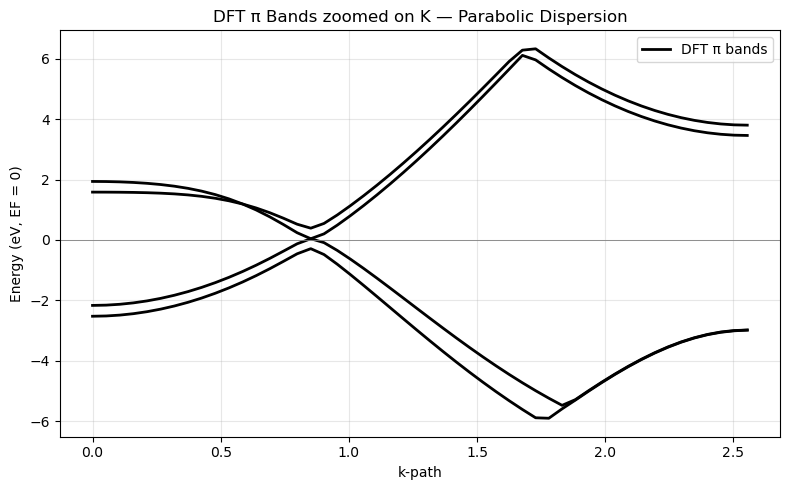

In [97]:
from bandplot import plot_bands

# Load the zoomed bands
kpts_zoom, band_energies_zoom, band_indices_zoom, EF_zoom = load_pi_dft_bands()

# Number of π bands in zoom region
nb = band_energies_zoom.shape[1]

# Build dataset dictionary
bands = {
    "DFT π bands": {
        "E": band_energies_zoom,   # shape (Nk, nb)
        "color": "k",
        "ls": "-",
        "lw": 2,
    }
}

# Plot
plot_bands(
    kpts_zoom,
    bands,
    title="DFT π Bands zoomed on K — Parabolic Dispersion",
    ylabel="Energy (eV, EF = 0)"
)


Notice the parabolic curve, which is correct.

## DFT DOS


In [91]:
import matplotlib.pyplot as plt
import numpy as np

In [92]:
e, dos = calc.get_dos(spin=0, npts=2001, width=0.2)

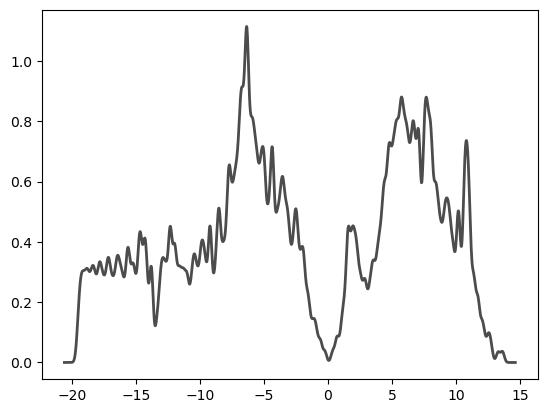

In [93]:
plt.plot(e - EF, dos, label='Total', c='k', lw=2, alpha=0.7)

In [94]:
dist = abs(E_pi.mean(axis=0) - EF)
idx_pi = np.argsort(dist)[:4]   # 4 π bands in bilayer
print("π-band indices:", idx_pi)


π-band indices: [0 2 1 3]


In [64]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
import importlib
import pdos_plotter

importlib.reload(pdos_plotter)   # reloads the module
from pdos_plotter import plot_pdos_pi_sigma   #

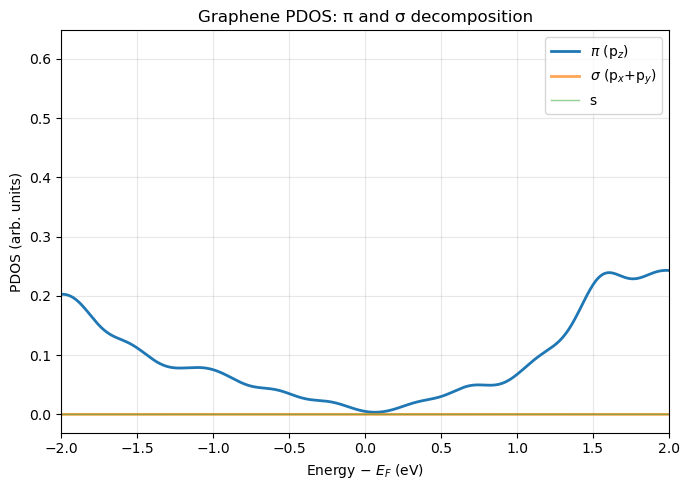

Saved interactive PDOS to: ../data/graphene_pdos_interactive.html


In [96]:
from pdos_plotter import plot_pdos_pi_sigma

# assuming you already have:
# atoms, calc = restart('yourfile.gpw')
plot_pdos_pi_sigma(calc, atoms, atom_indices=[0,1,2,3,], zoom=(-2, 2), save_html=True)

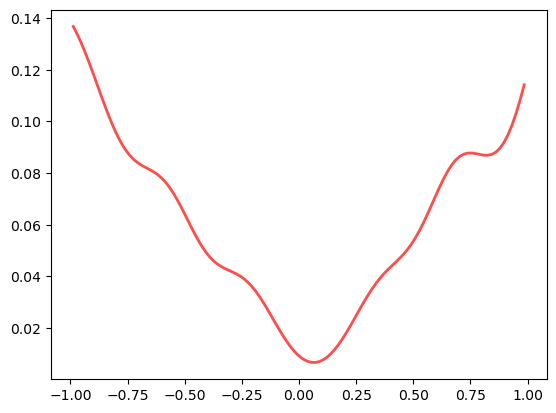

In [14]:
e_min_EF = e - EF
filter = (e_min_EF > -1) & (e_min_EF < 1)
plt.plot(e_min_EF[filter], dos[filter], label='Band', c='r', lw=2, alpha=0.7)

In [17]:
dos[filter].min()

np.float64(0.006618160771627887)

## Trigonal warping

In [186]:
import importlib
import trigonal_warping

importlib.reload(trigonal_warping)   # reloads the module
from gpaw import restart
from trigonal_warping import (
    compute_patch_bands,
    find_pi_bands,
    plot_trigonal_warping,
    plot_trigonal_warping_3d
)

In [ ]:
# Load your converged bilayer AB calc
atoms, calc = restart("../gpw/ab.gpw")
Nq=61
# 1) Compute dense patch around K
qx, qy, E_shifted, EF = compute_patch_bands(
    calc,
    atoms,
    radius=0.012,   # try 0.03, then maybe smaller like 0.015
    Nq=Nq,         # 41–81 is reasonable
    #nbands=None,  # or explicitly if needed
    txt="tw_blg_patch.txt"
)


going to generate bandpath
generated bandpath
Starting to compute the energies...


the closest energies to 0 are [7 8 6 9], [[[-0.03860202  0.13919779 -0.38806255  0.46672411]
  [-0.03667664  0.13609157 -0.38034452  0.46033403]
  [-0.03547582  0.13386808 -0.37382927  0.4549612 ]
  ...
  [-0.10985377  0.2260559  -0.50900854  0.56915271]
  [-0.1211262   0.23897552 -0.52379369  0.58185656]
  [-0.13285701  0.25234356 -0.53886433  0.5948306 ]]

 [[-0.03035872  0.13012153 -0.3832624   0.46302192]
  [-0.02791603  0.12635397 -0.37481832  0.45606777]
  [-0.02636922  0.12363079 -0.36753201  0.45009556]
  ...
  [-0.09800465  0.21247943 -0.49402726  0.556363  ]
  [-0.10933567  0.22550408 -0.50876386  0.56897009]
  [-0.12112644  0.23897579 -0.52379383  0.58185672]]

 [[-0.02291288  0.12197623 -0.37928382  0.45995904]
  [-0.01977544  0.11737385 -0.37013843  0.45246414]
  [-0.01773036  0.1139984  -0.36209824  0.44591082]
  ...
  [-0.08661406  0.1993462  -0.4793482   0.54386319]
  [-0.09800492  0.21247973 -0.49402742  0.55636318]
  [-0.10985428  0.22605646 -0.50900883  0.56915305]]


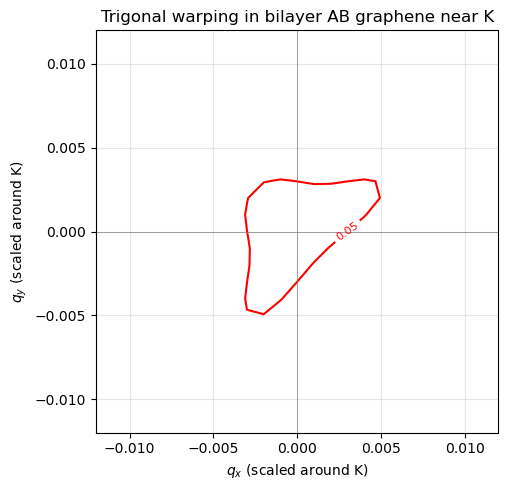

In [268]:
# 2) Select the lowest-energy conduction band (or two bands closest to EF)
#idx, E_low = select_low_energy_bands(E_shifted, n_bands=16)
#print("Low-energy band indices near EF:", idx)
#BE_low = E_shifted[:4]
import numpy as np
idx_pi, E_pi = find_pi_bands(E_shifted, n=4)

print("π-band indices (closest to EF):", idx_pi)


avg_pi = E_pi.mean(axis=(0,1))

# select entries > 0 (conduction)
pos = np.where(avg_pi > 0)[0]

if len(pos) == 0:
    raise RuntimeError("No positive-energy π conduction band found!")

# choose the conduction π band closest to zero
cond_idx_local = pos[np.argmin(avg_pi[pos])]

E_cond = E_pi[..., cond_idx_local]
print("Using conduction π band:", idx_pi[cond_idx_local])

# 3) Plot iso-energy contours at ±10 meV
plot_trigonal_warping(
    qx, qy, E_cond,
    E_iso=0.05,   # 10 meV in eV units
    title="Trigonal warping in bilayer AB graphene near K"
)

In [259]:
ix0, iy0 = E_cond.shape[0] // 2, E_cond.shape[1] // 2
print("E_cond at K (center) =", E_cond[ix0, iy0], "eV")


E_cond at K (center) = 0.040618738977389324 eV


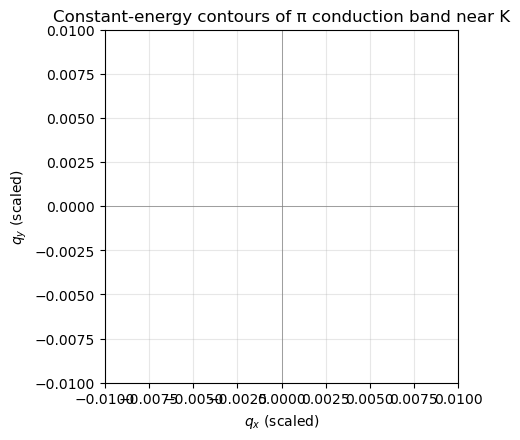

In [83]:
E_cond

array([[1.46225245, 1.22632705, 1.13757261, 1.13757261, 1.22632704,
        1.46225244, 1.79053494, 2.16880324, 2.57215786, 2.98630358,
        3.40263609],
       [1.46746835, 1.17193304, 0.98995833, 0.95757679, 0.98995833,
        1.17193302, 1.46746833, 1.8214211 , 2.20224183, 2.59349865,
        2.98630458],
       [1.47125772, 1.1374428 , 0.87193161, 0.74428197, 0.74428197,
        0.8719316 , 1.13744278, 1.47125769, 1.83237793, 2.20224302,
        2.57216001],
       [1.47125923, 1.12564393, 0.80417483, 0.56254168, 0.48821126,
        0.56254166, 0.8041748 , 1.12564389, 1.47125919, 1.82142371,
        2.16880671],
       [1.46747277, 1.13744633, 0.80417708, 0.48297739, 0.25280394,
        0.25280392, 0.48297735, 0.80417704, 1.13744629, 1.46747273,
        1.79054001],
       [1.4622595 , 1.1719397 , 0.87193778, 0.56254722, 0.25280863,
        0.04061874, 0.2528086 , 0.56254717, 0.87193773, 1.17193965,
        1.46225944],
       [1.45934378, 1.2263362 , 0.98996723, 0.7442902 , 0.

In [260]:
Nq_x, Nq_y, Nbands = E_shifted.shape
E_cond = np.empty((Nq_x, Nq_y))

for ix in range(Nq_x):
    for iy in range(Nq_y):
        Ek = E_shifted[ix, iy, :]  # all bands at this k
        pos = Ek[Ek > 0.0]
        if pos.size == 0:
            # no positive band here, fall back to least negative
            E_cond[ix, iy] = np.max(Ek)
        else:
            E_cond[ix, iy] = np.min(pos)   # smallest positive = conduction

E_cond

array([[4.06268428e-01, 3.90138569e-01, 3.77667323e-01, 3.68679081e-01,
        3.62796945e-01, 3.59542794e-01, 3.58511275e-01, 3.59542793e-01,
        3.62796942e-01, 3.68679076e-01, 3.77667316e-01, 3.90138560e-01,
        4.06268415e-01, 4.26014895e-01, 4.49161489e-01, 4.75383447e-01,
        5.04308904e-01, 5.35563585e-01, 5.68799095e-01, 6.03704563e-01,
        6.40010912e-01, 6.77488962e-01, 7.15944656e-01, 7.55215824e-01,
        7.95166439e-01],
       [3.86453620e-01, 3.67414314e-01, 3.52216343e-01, 3.40845937e-01,
        3.33028324e-01, 3.28281610e-01, 3.26081013e-01, 3.26081012e-01,
        3.28281608e-01, 3.33028319e-01, 3.40845930e-01, 3.52216334e-01,
        3.67414301e-01, 3.86453605e-01, 4.09123274e-01, 4.35068739e-01,
        4.63872623e-01, 4.95113971e-01, 5.28402731e-01, 5.63396233e-01,
        5.99801591e-01, 6.37373932e-01, 6.75908112e-01, 7.15235543e-01,
        7.55216119e-01],
       [3.69270852e-01, 3.47081756e-01, 3.28796588e-01, 3.14612456e-01,
        3.0443

In [269]:
# at K
E_center = E_shifted[Nq//2, Nq//2, :]
eps = np.abs(E_center)

# find the (positive) π band: smallest positive energy
candidates = np.where(E_center > 0)[0]
cond_idx = candidates[np.argmin(E_center[candidates])]


In [270]:
E_cond = E_shifted[..., cond_idx]


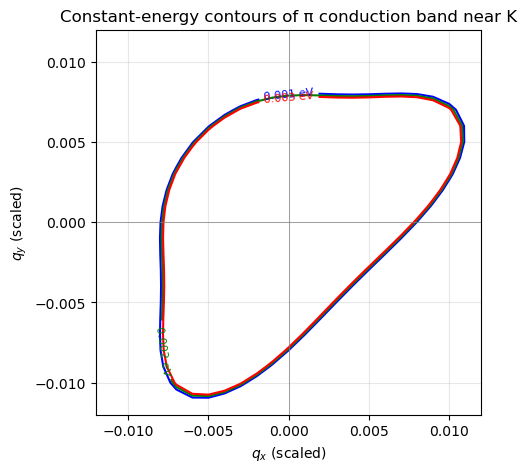

In [271]:
import matplotlib.pyplot as plt
import numpy as np

# E_cond: (Nq, Nq) conduction π band, shifted so EF=0
# qx, qy: (Nq, Nq) mesh (scaled around K)

plt.figure(figsize=(5, 5))

# choose a few low energies in eV
levels = [0.0010, 0.0018, 0.0025]
cs = plt.contour(qx, qy, E_cond, levels=levels, colors=['b', 'g', 'r'])
plt.clabel(cs, inline=True, fontsize=8, fmt="%.3f eV")

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal', 'box')

plt.xlabel(r"$q_x$ (scaled)")
plt.ylabel(r"$q_y$ (scaled)")
plt.title("Constant-energy contours of π conduction band near K")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [272]:
plot_trigonal_warping_3d(
    qx,
    qy,
    E_cond,
    #E_shifted[:, :, 8],
    #E_pi[:, :, 1],
   # title=f"Trigonal warping near K (band {idx[0]})",
    zlim=(-0.04, 0.1),  # in eV
    save_html=True,
    html_path="../data/trigonal_warping_3d.html",
)

Saved interactive 3D trigonal-warping plot to: ../data/trigonal_warping_3d.html


In [45]:
E_band

array([[-0.07309532, -0.0664356 , -0.06439658, -0.06439658, -0.0664356 ,
        -0.07309531, -0.08697749, -0.10865099, -0.1369606 , -0.17027752,
        -0.20720544],
       [-0.05007272, -0.03860202, -0.0348123 , -0.03435658, -0.0348123 ,
        -0.03860201, -0.0500727 , -0.07076015, -0.09910419, -0.13285701,
        -0.17027813],
       [-0.03624026, -0.01653106, -0.0081132 , -0.007328  , -0.00732799,
        -0.0081132 , -0.01653105, -0.03624024, -0.06483551, -0.09910499,
        -0.13696197],
       [-0.03624137, -0.00724523,  0.01189764,  0.01653465,  0.01513355,
         0.01653465,  0.01189766, -0.0072452 , -0.03624134, -0.07076194,
        -0.10865324],
       [-0.0500756 , -0.01653348,  0.01189598,  0.03179596,  0.03305095,
         0.03305095,  0.03179597,  0.011896  , -0.01653345, -0.05007557,
        -0.08698067],
       [-0.07309928, -0.03860572, -0.00811649,  0.01653203,  0.03304943,
         0.04060006,  0.03304944,  0.01653205, -0.00811646, -0.03860569,
        -0.073